# Data & Modèle — Classifieur d'espèces de plantes

Partie : chargement du dataset, construction du modèle (MobileNetV2, transfer learning), entraînement, sauvegarde.

Dataset : Oxford 102 Flowers (`tensorflow_datasets`, `oxford_flowers102`).

In [1]:
!pip install -q tensorflow tensorflow-datasets matplotlib

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import json

IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

## 1. Chargement et inspection du dataset

In [14]:
(ds_train, ds_val, ds_test), ds_info = tfds.load(
    "oxford_flowers102",
    split=["train", "validation", "test"],
    as_supervised=True,
    with_info=True,
)

NUM_CLASSES = ds_info.features["label"].num_classes
CLASS_NAMES = ds_info.features["label"].names
mapping = {str(i): nom_espece for i, nom_espece in enumerate(CLASS_NAMES)}
with open('flower_mapping.json', 'w') as f:
    json.dump(mapping, f)
    
print(f"Nombre de classes : {NUM_CLASSES}")
print(f"Train : {ds_info.splits['train'].num_examples} exemples")
print(f"Validation : {ds_info.splits['validation'].num_examples} exemples")
print(f"Test : {ds_info.splits['test'].num_examples} exemples")

Nombre de classes : 102
Train : 1020 exemples
Validation : 1020 exemples
Test : 6149 exemples


Shape image : (500, 667, 3) dtype : <dtype: 'uint8'>
Label : 72 water lily


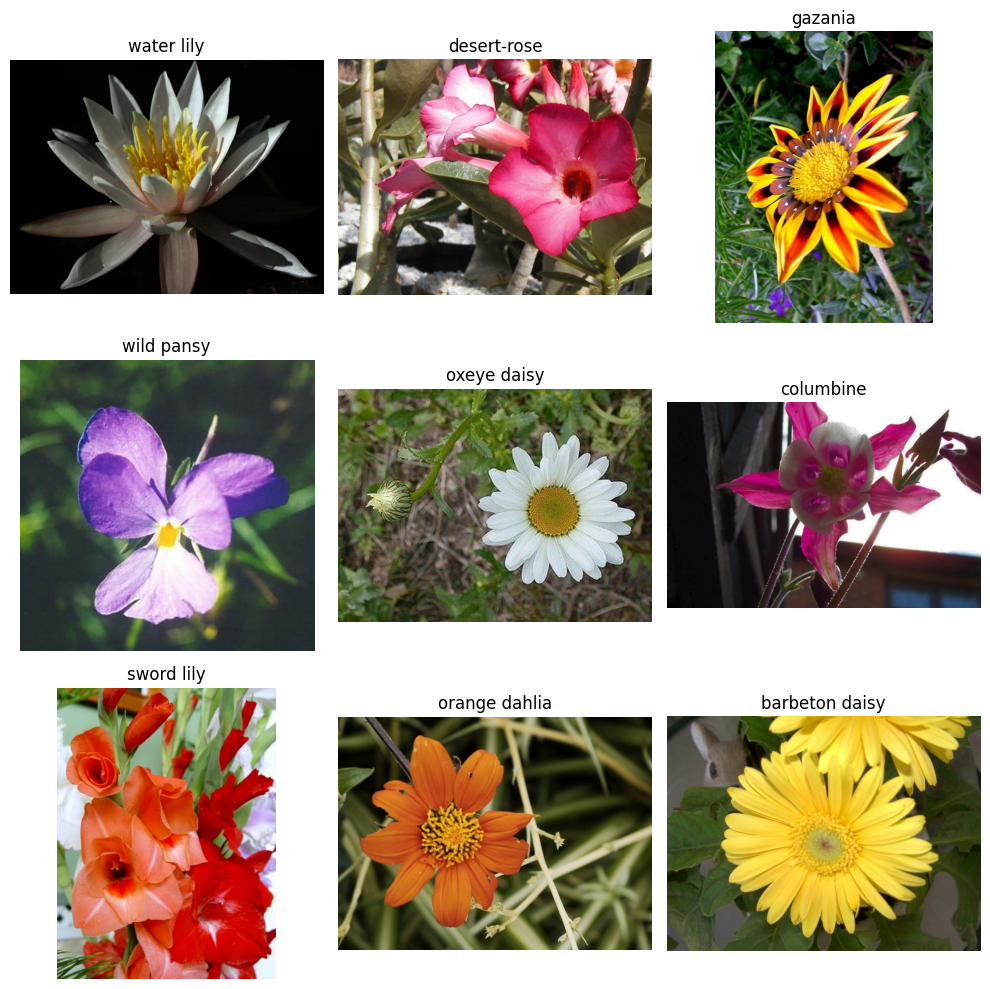

In [4]:
# Inspection des shapes et exemples d'images
for image, label in ds_train.take(1):
    print("Shape image :", image.shape, "dtype :", image.dtype)
    print("Label :", label.numpy(), CLASS_NAMES[label.numpy()])

plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(ds_train.take(9)):
    plt.subplot(3, 3, i + 1)
    plt.imshow(image)
    plt.title(CLASS_NAMES[label.numpy()])
    plt.axis("off")
plt.tight_layout()
plt.show()

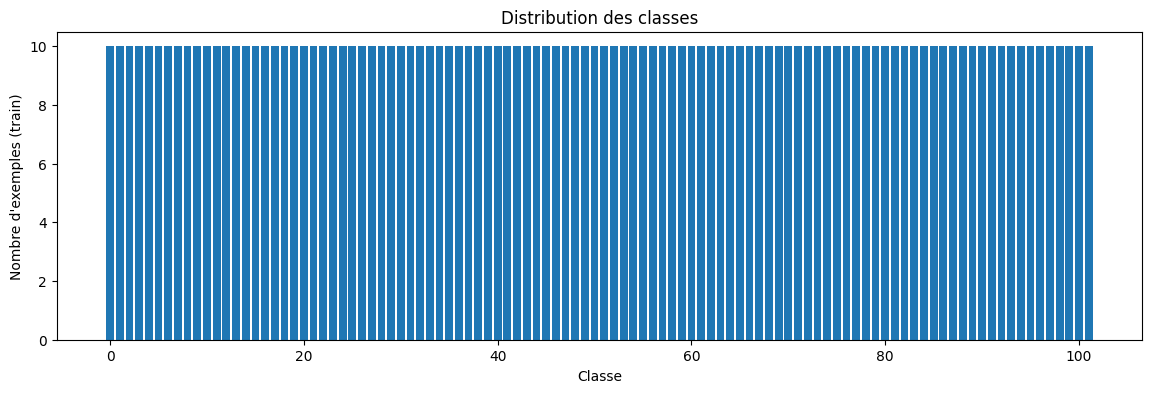

Min par classe : 10, Max par classe : 10


In [5]:
# Distribution des classes (train) - vérifier l'équilibre avant de décider le split
labels = [int(label.numpy()) for _, label in ds_train]
counts = np.bincount(labels, minlength=NUM_CLASSES)

plt.figure(figsize=(14, 4))
plt.bar(range(NUM_CLASSES), counts)
plt.xlabel("Classe")
plt.ylabel("Nombre d'exemples (train)")
plt.title("Distribution des classes")
plt.show()

print(f"Min par classe : {counts.min()}, Max par classe : {counts.max()}")

## 2. Préparation des pipelines (resize, normalisation, batch)

In [6]:
def preprocess(image, label):
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, NUM_CLASSES)
    return image, label


train_ds = (
    ds_train.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = ds_val.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = ds_test.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## 3. Construction du modèle v2 — data augmentation + fine-tuning partiel

Contrairement à la v1 (couches gelées, pas d'augmentation), cette version :
- ajoute de la data augmentation (flip, rotation, zoom)
- dégèle les 30 dernières couches de MobileNetV2 pour un fine-tuning léger

couche d'augmentation :

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

modèle avec fine-tuning partiel :

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMAGE_SIZE + (3,),
    include_top=False,
    weights="imagenet",
)
base_model.trainable = True
# On ne dégèle que les 30 dernières couches (fine-tuning léger)
for layer in base_model.layers[:-30]:
    layer.trainable = False

inputs = tf.keras.Input(shape=IMAGE_SIZE + (3,))
x = data_augmentation(inputs)  # appliqué seulement pendant l'entraînement
x = tf.keras.applications.mobilenet_v2.preprocess_input(x * 255.0)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model_v2 = tf.keras.Model(inputs, outputs)
model_v2.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 102)            │       130,662 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,388,646 (9.11 MB)

 Trainable params: 1,657,062 (6.32 MB)

 Non-trainable params: 731,584 (2.79 MB)

## 4. Compilation et entraînement (v2)

In [9]:
model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
)

Epoch 1/10


c:\Users\Batyste\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 300ms/step - accuracy: 0.0343 - loss: 4.6735 - val_accuracy: 0.0304 - val_loss: 4.5622
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 272ms/step - accuracy: 0.3039 - loss: 3.4155 - val_accuracy: 0.1098 - val_loss: 3.9164
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 279ms/step - accuracy: 0.5657 - loss: 2.3967 - val_accuracy: 0.2020 - val_loss: 3.3748
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 275ms/step - accuracy: 0.7343 - loss: 1.6474 - val_accuracy: 0.2931 - val_loss: 2.9374
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 277ms/step - accuracy: 0.8520 - loss: 1.1228 - val_accuracy: 0.3520 - val_loss: 2.6378
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 274ms/step - accuracy: 0.9010 - loss: 0.8117 - val_accuracy: 0.4010 - val_loss: 2.4098
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 279ms/step - accuracy: 0.9382 - loss: 0.5898 - val_accuracy: 0.4500 - val_loss: 2.1482
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 285ms/step - accuracy: 0.9676 - loss: 0.4321 - val_accuracy: 0.4892 - val

## 5. Évaluation sur le test set et sauvegarde

In [16]:
from pathlib import Path

save_path = Path("..") / "models" / "model_v2_augmented.keras"
save_path.parent.mkdir(parents=True, exist_ok=True)

test_loss_v2, test_acc_v2 = model_v2.evaluate(test_ds)
print(f"Test accuracy v2 : {test_acc_v2:.2%} (baseline aléatoire : {1 / NUM_CLASSES:.2%})")

model_v2.save(save_path)
print(f"Modèle v2 sauvegardé dans : {save_path}")

193/193 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step - accuracy: 0.5308 - loss: 1.7913
Test accuracy v2 : 53.08% (baseline aléatoire : 0.98%)
Modèle v2 sauvegardé dans : ..\models\model_v2_augmented.keras


## preparation de la comparaison

1.   Élément de liste
2.   Élément de liste

In [11]:
print("=== Comparaison rapide ===")
print(f"v1 (Ahmad, baseline)     : voir son notebook pour test_accuracy")
print(f"v2 (augmenté + fine-tuné) : {test_acc_v2:.2%}")
print(f"Baseline aléatoire        : {1/NUM_CLASSES:.2%}")

=== Comparaison rapide ===
v1 (Ahmad, baseline)     : voir son notebook pour test_accuracy
v2 (augmenté + fine-tuné) : 53.08%
Baseline aléatoire        : 0.98%
